In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv('Downloads/wine_data.csv', header = None, usecols=[0,1,2])

In [31]:
df

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [32]:
df.columns = ['class label', 'Alchohal', 'Malic acid']

In [33]:
df

,class label,Alchohal,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alchohal', ylabel='Density'>

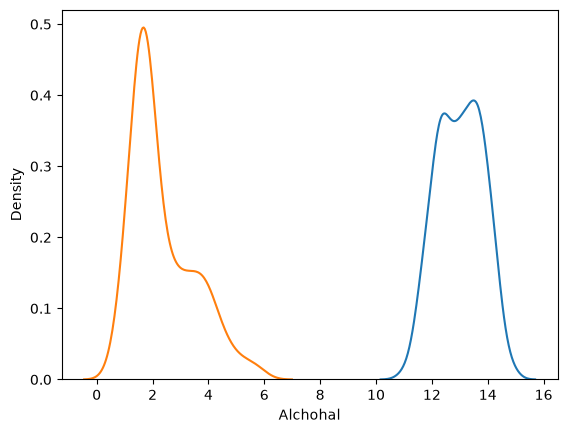

In [34]:
sns.kdeplot(df['Alchohal'])
sns.kdeplot(df['Malic acid'])


<Axes: xlabel='Alchohal', ylabel='Malic acid'>

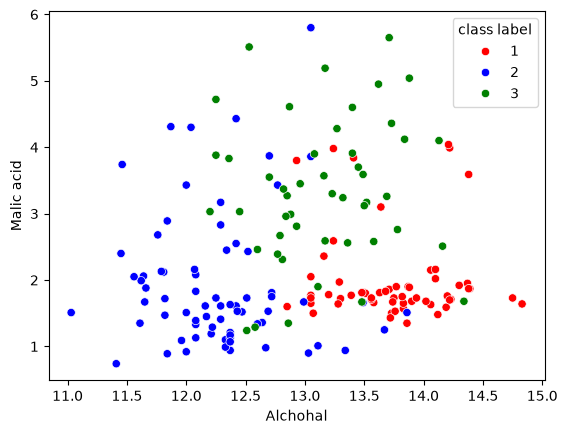

In [35]:
color_dict = {1 : 'red', 2:'blue', 3:'green'}
sns.scatterplot(x= df['Alchohal'],y=df['Malic acid'], hue=df['class label'], palette=color_dict)

In [36]:
#Training 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('class label', axis = 1),
                                                 df['class label'], test_size = 0.3,
                                                 random_state = 0)
                                            

In [37]:
x_train.shape, x_test.shape

((124, 2), (54, 2))

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
scaler = MinMaxScaler()

In [40]:
scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](2,)","[14.75, 5.65]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](2,)","[11.03, 0.89]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](2,)","[3.72,4.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Alchohal','Malic acid']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](2,)","[-2.97,-0.19]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,124


In [41]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [42]:
x_train_scaled = pd.DataFrame(x_train, columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test, columns = x_test.columns)

In [43]:
import numpy as np

In [44]:
np.round(x_train.describe(), 1)

,Alchohal,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [45]:
np.round(x_train_scaled.describe(), 1)

,Alchohal,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [49]:
x_train

,Alchohal,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [47]:
df.sample(5)

,class label,Alchohal,Malic acid
118,2,12.77,3.43
177,3,14.13,4.10
120,2,11.45,2.40
144,3,12.25,3.88
60,2,12.33,1.10


In [48]:
df.tail()

,class label,Alchohal,Malic acid
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59
177,3,14.13,4.10


Text(0.5, 1.0, 'After Scaling')

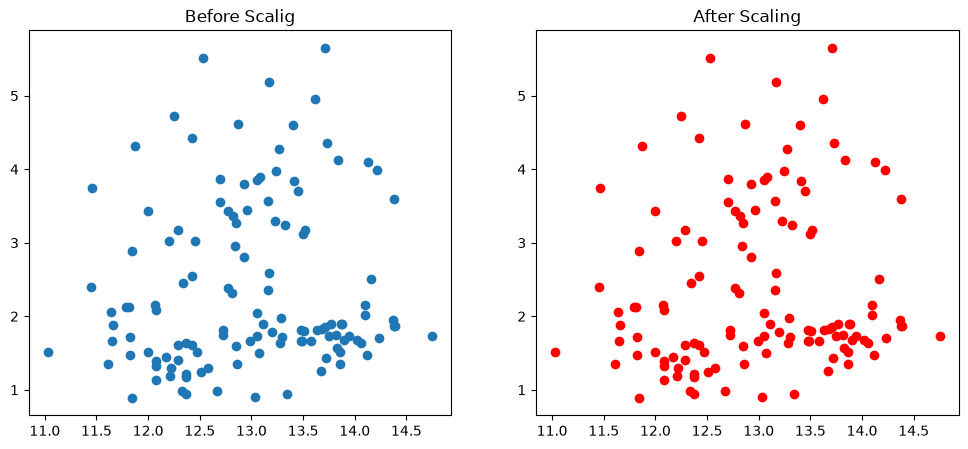

In [58]:
#visualization
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))
ax1.scatter(x_train['Alchohal'], x_train['Malic acid'])
ax1.set_title('Before Scalig')
#After scaling
ax2.scatter(x_train_scaled['Alchohal'], x_train_scaled['Malic acid'], c='red')
ax2.set_title('After Scaling')

<Axes: title={'center': 'After Scaling'}, xlabel='Alchohal', ylabel='Density'>

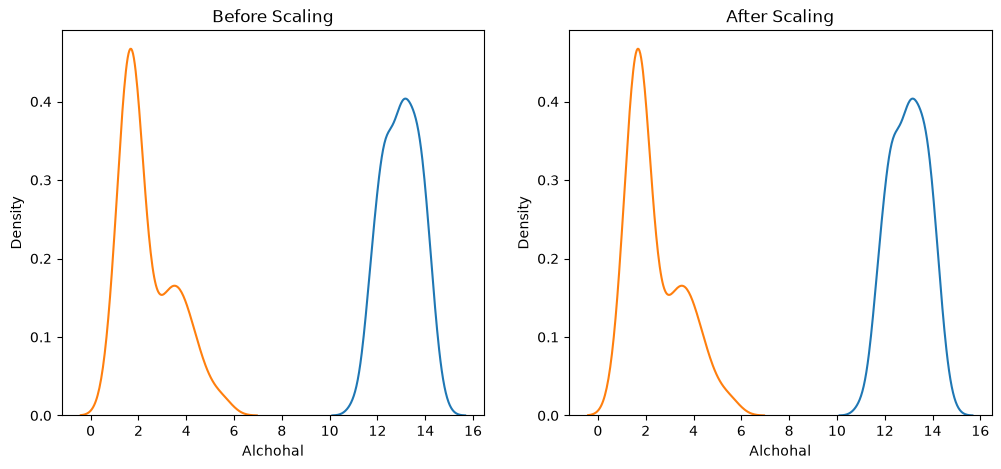

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))
#Before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Alchohal'], ax=ax1)
sns.kdeplot(x_train['Malic acid'], ax=ax1)
# After scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Alchohal'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)

<Axes: xlabel='Alchohal', ylabel='Density'>

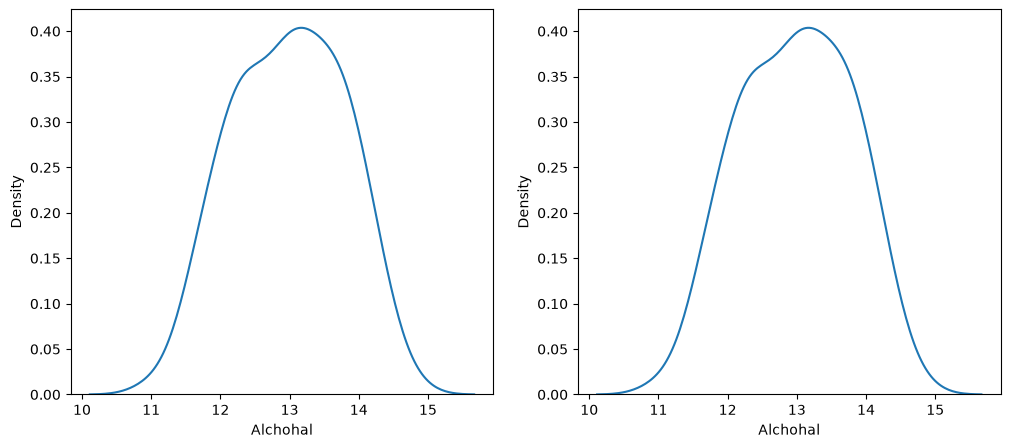

In [70]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))
#before scaling
sns.kdeplot(x_train['Alchohal'], ax=ax1)
#after scaling
sns.kdeplot(x_train_scaled['Alchohal'], ax=ax2)



<Axes: xlabel='Malic acid', ylabel='Density'>

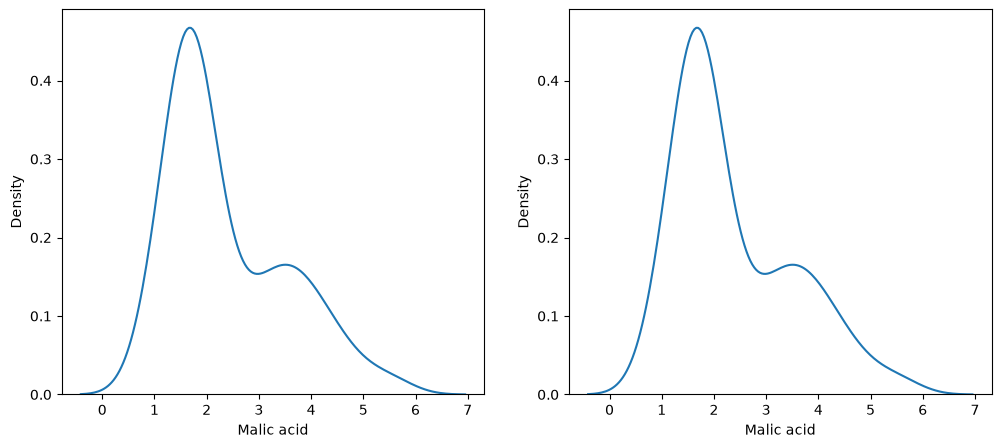

In [72]:
#for malic acid
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))
#before scaling
sns.kdeplot(x_train['Malic acid'], ax=ax1)
#after scaling
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
